In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

In [66]:
def generate_rdm(size=(128,128), num_targets=6):
    
    noise = rayleigh.rvs(scale=1.0, size=size)
    rdm = noise.copy()
    
    targets = []

    for _ in range(num_targets):
        r = np.random.randint(0, size[0])
        d = np.random.randint(0, size[1])
        rdm[r, d] += np.random.uniform(10, 20)
        targets.append((r, d))

    return rdm, targets

rdm, true_targets = generate_rdm()

In [67]:
def mc_cfar(rdm, M=2000, k_ratio=0.1, q_ratio=0.1, alpha=3.3):
    
    R, D = rdm.shape

    # Monte Carlo sampling
    all_indices = np.arange(R * D)
    sampled_indices = np.random.choice(all_indices, size=M, replace=False)
    r_idx, d_idx = np.unravel_index(sampled_indices, (R, D))
    
    samples = rdm[r_idx, d_idx]

    # Sort
    samples_sorted = np.sort(samples)

    k = int(k_ratio * M)
    q = int(q_ratio * M)

    # Remove extremes
    valid_samples = samples_sorted[q:M-k]

    # Noise estimate
    mu = np.mean(valid_samples)

    # Threshold
    threshold = alpha * mu

    # Detection
    detections = (rdm > threshold).astype(int)

    return threshold, detections, mu

In [68]:
threshold, detections, mu = mc_cfar(rdm)

print("Noise Mean:", mu)
print("Threshold:", threshold)

Noise Mean: 1.1999726971995273
Threshold: 3.95990990075844


In [69]:
correct = sum(detections[r, d] for (r, d) in true_targets)

false_alarms = np.sum(detections) - correct

Pd = correct / len(true_targets)
Pfa = false_alarms / rdm.size

print("True Targets:", len(true_targets))
print("Correctly Detected:", correct)
print("Detection Probability (Pd):", Pd)
print("False Alarm Rate (Pfa):", Pfa)

True Targets: 6
Correctly Detected: 6
Detection Probability (Pd): 1.0
False Alarm Rate (Pfa): 0.00048828125


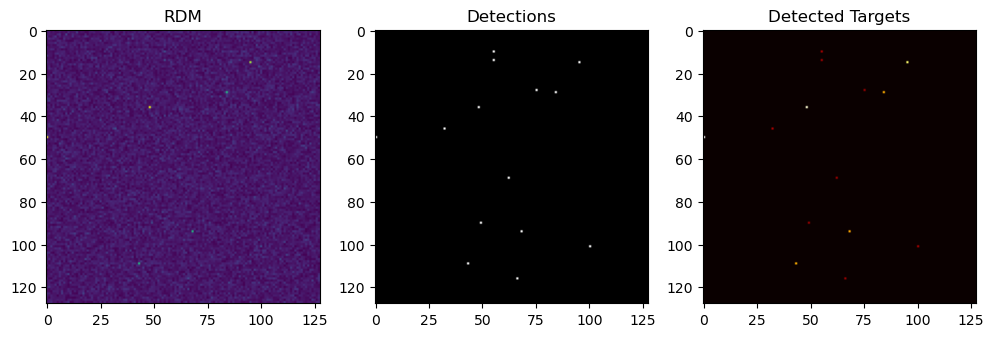

In [70]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("RDM")
plt.imshow(rdm, cmap='viridis')

plt.subplot(1,3,2)
plt.title("Detections")
plt.imshow(detections, cmap='gray')

plt.subplot(1,3,3)
plt.title("Detected Targets")
plt.imshow(rdm * detections, cmap='hot')

plt.show()

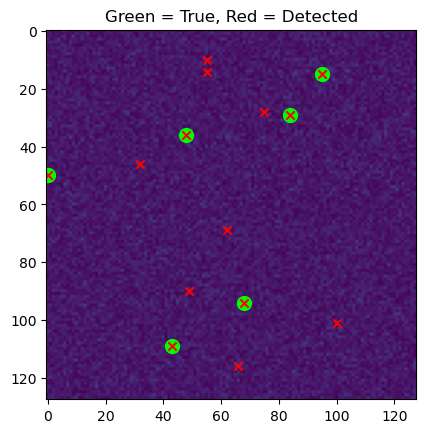

In [71]:
plt.imshow(rdm, cmap='viridis')

# True targets → GREEN
for (r, d) in true_targets:
    plt.scatter(d, r, color='lime', marker='o',s=100)

# Detected → RED
detected_points = np.argwhere(detections == 1)
for (r, d) in detected_points:
    plt.scatter(d, r, color='red', marker='x')

plt.title("Green = True, Red = Detected")
plt.show()

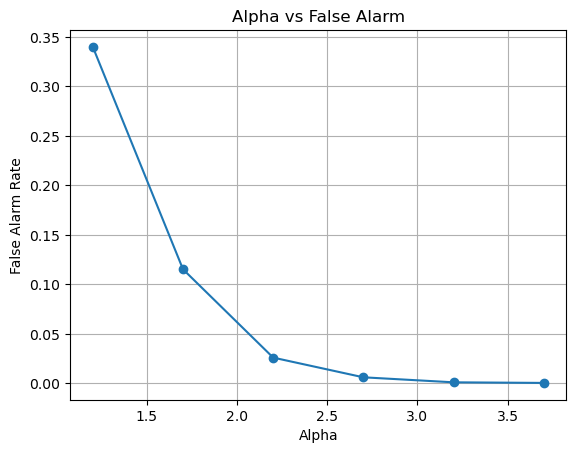

In [72]:
alphas = np.linspace(1.2, 3.7, 6)
false_alarms = []

for a in alphas:
    _, det, _ = mc_cfar(rdm, alpha=a)
    fa = np.sum(det) / det.size
    false_alarms.append(fa)

plt.plot(alphas, false_alarms, marker='o')
plt.xlabel("Alpha")
plt.ylabel("False Alarm Rate")
plt.title("Alpha vs False Alarm")
plt.grid()
plt.show()